# Autoencoder Fashion-MNIST
Training Autoencoder untuk rekonstruksi citra Fashion-MNIST dengan variasi latent dimension.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [2]:
class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, stride=2, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, stride=2, padding=1)
        self.fc = nn.Linear(32 * 7 * 7, latent_dim)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x


class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 32 * 7 * 7)
        self.deconv1 = nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1)
        self.deconv2 = nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1)

    def forward(self, z):
        z = torch.relu(self.fc(z))
        z = z.view(z.size(0), 32, 7, 7)
        z = torch.relu(self.deconv1(z))
        z = torch.sigmoid(self.deconv2(z))
        return z


class Autoencoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

In [3]:
# Deteksi environment: Kaggle atau lokal
possible_paths = [
    '/kaggle/input/fashion-mnist',
    '/kaggle/input/fashionmnist',
    '/kaggle/input/datasets/organizations/zalando-research/fashionmnist',
]

csv_found = None
for p in possible_paths:
    train_csv = os.path.join(p, 'fashion-mnist_train.csv')
    if os.path.exists(train_csv):
        csv_found = p
        print(f'Kaggle dataset ditemukan di: {p}')
        break

if csv_found:
    # Load dari CSV (Kaggle)
    train_df = pd.read_csv(os.path.join(csv_found, 'fashion-mnist_train.csv'))
    test_df = pd.read_csv(os.path.join(csv_found, 'fashion-mnist_test.csv'))

    X_train = train_df.iloc[:, 1:].values.astype(np.float32) / 255.0
    X_test = test_df.iloc[:, 1:].values.astype(np.float32) / 255.0

    X_train = X_train.reshape(-1, 1, 28, 28)
    X_test = X_test.reshape(-1, 1, 28, 28)

    train_dataset = TensorDataset(torch.tensor(X_train), torch.tensor(X_train))
    test_dataset = TensorDataset(torch.tensor(X_test), torch.tensor(X_test))
else:
    # Load dari torchvision (local)
    from torchvision import datasets, transforms
    transform = transforms.Compose([transforms.ToTensor()])
    train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
    test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
    print('Dataset loaded via torchvision')

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

print(f'Train: {len(train_dataset)}, Test: {len(test_dataset)}')

Kaggle dataset ditemukan di: /kaggle/input/datasets/organizations/zalando-research/fashionmnist
Train: 60000, Test: 10000


In [4]:
LATENT_DIMS = [2, 8, 32]
EPOCHS = 20
all_losses = {}
all_models = {}

for latent_dim in LATENT_DIMS:
    print(f'\n========== Training latent_dim = {latent_dim} ==========')
    model = Autoencoder(latent_dim).to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    epoch_losses = []

    for epoch in range(1, EPOCHS + 1):
        total_loss = 0
        for images, _ in train_loader:
            images = images.to(device)
            outputs = model(images)
            loss = criterion(outputs, images)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * images.size(0)
        avg_loss = total_loss / len(train_loader.dataset)
        epoch_losses.append(avg_loss)
        if epoch % 5 == 0 or epoch == 1:
            print(f'Epoch {epoch:2d}/{EPOCHS} - Loss: {avg_loss:.6f}')

    all_losses[latent_dim] = epoch_losses
    all_models[latent_dim] = model
    torch.save(model.state_dict(), f'autoencoder_fashion_mnist_dim{latent_dim}.pth')
    torch.save(model.encoder.state_dict(), f'encoder_fashion_mnist_dim{latent_dim}.pth')
    torch.save(model.decoder.state_dict(), f'decoder_fashion_mnist_dim{latent_dim}.pth')
    print(f'Model dim={latent_dim} saved. Final loss: {epoch_losses[-1]:.6f}')

print('\nTraining selesai!')


========== Training latent_dim = 2 ==========
Epoch  1/20 - Loss: 0.064368
Epoch  5/20 - Loss: 0.035426
Epoch 10/20 - Loss: 0.033532
Epoch 15/20 - Loss: 0.032632
Epoch 20/20 - Loss: 0.031992
Model dim=2 saved. Final loss: 0.031992

========== Training latent_dim = 8 ==========
Epoch  1/20 - Loss: 0.046428
Epoch  5/20 - Loss: 0.018725
Epoch 10/20 - Loss: 0.016924
Epoch 15/20 - Loss: 0.016054
Epoch 20/20 - Loss: 0.015475
Model dim=8 saved. Final loss: 0.015475

========== Training latent_dim = 32 ==========
Epoch  1/20 - Loss: 0.032005
Epoch  5/20 - Loss: 0.010232
Epoch 10/20 - Loss: 0.008855
Epoch 15/20 - Loss: 0.008314
Epoch 20/20 - Loss: 0.008001
Model dim=32 saved. Final loss: 0.008001

Training selesai!


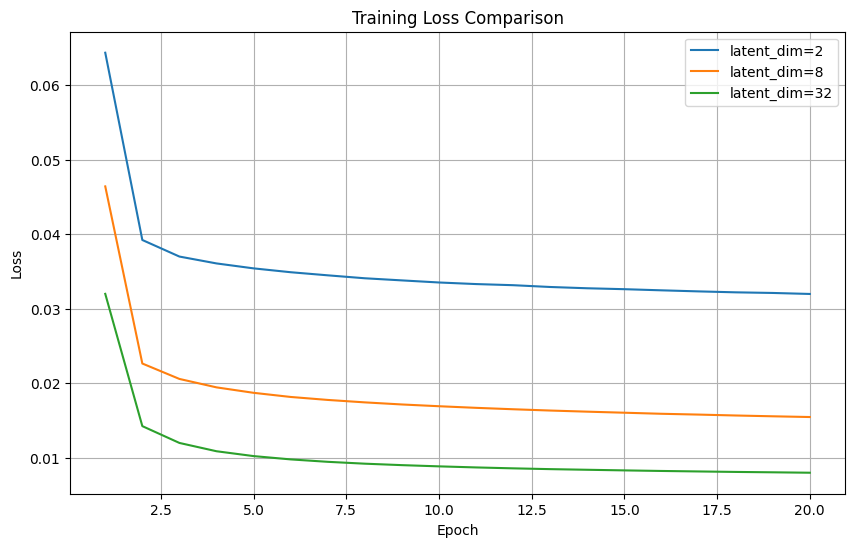

In [5]:
plt.figure(figsize=(10, 6))
for dim, losses in all_losses.items():
    plt.plot(range(1, EPOCHS + 1), losses, label=f'latent_dim={dim}')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Comparison')
plt.legend()
plt.grid(True)
plt.savefig('training_loss_comparison.png', bbox_inches='tight')
plt.show()

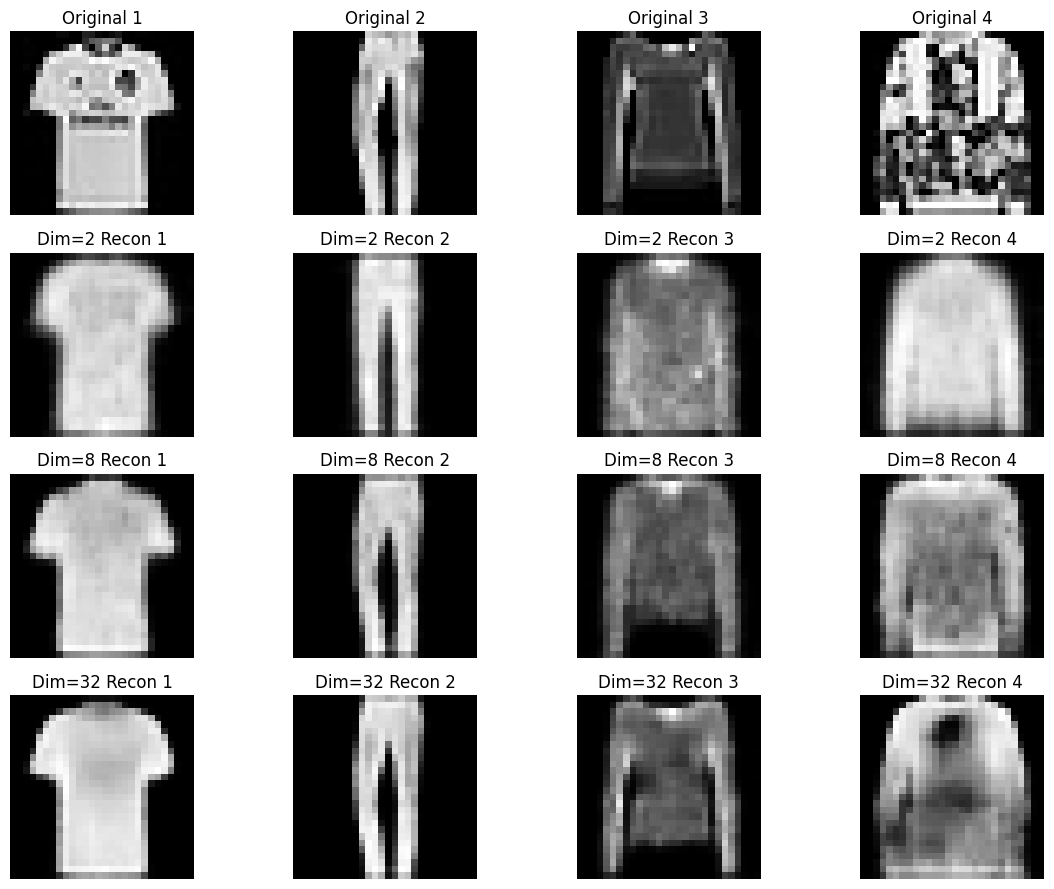

In [6]:
for batch in test_loader:
    images, _ = batch
    break
images = images[:4].to(device)

fig, axes = plt.subplots(len(LATENT_DIMS) + 1, 4, figsize=(12, 9))
for col in range(4):
    axes[0, col].imshow(images[col].cpu().squeeze(), cmap='gray')
    axes[0, col].set_title(f'Original {col+1}')
    axes[0, col].axis('off')

for row, dim in enumerate(LATENT_DIMS):
    model = all_models[dim]
    model.eval()
    with torch.no_grad():
        reconstructed = model(images)
    for col in range(4):
        axes[row + 1, col].imshow(reconstructed[col].cpu().squeeze(), cmap='gray')
        axes[row + 1, col].set_title(f'Dim={dim} Recon {col+1}')
        axes[row + 1, col].axis('off')

plt.tight_layout()
plt.savefig('reconstruction_comparison.png', bbox_inches='tight')
plt.show()

In [7]:
print('Final losses per latent dimension:')
for dim, losses in all_losses.items():
    print(f'  latent_dim={dim:2d} -> Loss: {losses[-1]:.6f}')

Final losses per latent dimension:
  latent_dim= 2 -> Loss: 0.031992
  latent_dim= 8 -> Loss: 0.015475
  latent_dim=32 -> Loss: 0.008001
